<a href="https://colab.research.google.com/github/BhaveshJoshi934/RTR2020/blob/master/SimpleRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
NAVY = "#004BA0"
GOLD = "#D1AB3E"

In [44]:
df = pd.read_csv("IPLPlayerStat.csv")
print(df.shape)
df.head()

(605, 17)


,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [45]:
if "Unnamed: 0" in df.columns:
  df = df.drop(columns=["Unnamed: 0"])
print("Shape : ", df.shape)
df.head()

Shape :  (605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [46]:
df["balls_faced"].describe()

,balls_faced
count,605.000000
mean,373.477686
std,764.432561
min,1.000000
25%,18.000000
50%,73.000000
75%,285.000000
max,5266.000000


In [47]:
X = df[["balls_faced"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", round(model.intercept_, 2))
print("Slope:", round(model.coef_[0], 4))
print(f"\nMeaning: every extra balls faced adds ~{model.coef_[0]:.2f} runs on average.")

Intercept: -15.33
Slope: 1.2844

Meaning: every extra balls faced adds ~1.28 runs on average.


In [48]:
print(model.predict(X_train))

[ 2.47965349e+02  5.11261164e+02  7.20066825e+01  3.93508159e+00
 -1.27617262e+01  3.27596278e+02 -7.62424687e+00  6.08873271e+02
  7.78819108e+00  1.76040639e+02  3.34755877e+01  8.01528745e+02
  1.80631497e+01  1.14390887e+02  1.40078283e+02  9.07256091e+00
  3.84108551e+02 -1.14773564e+01 -1.27617262e+01  7.32910523e+01
  9.87762370e+02  1.36634193e+00  3.73286971e+01  2.90275778e+03
  4.90711247e+02  1.87599967e+02 -8.90861670e+00  2.44809087e+03
  8.61347506e+01  2.36406021e+02  9.89784489e+01  1.03569307e+01
  7.78819108e+00  2.08149884e+02  3.16036950e+02  1.32372064e+02
  8.19721054e-02  8.48503808e+01  9.78771782e+02  1.33656434e+02
  9.07256091e+00  6.43004635e+01 -5.05550721e+00  2.29984171e+02
  1.07969038e+02  5.40255049e+01  3.07046361e+02  8.48503808e+01
 -1.01929865e+01  1.43931393e+02  2.13287364e+02  3.86677291e+02
  2.65071176e+00  2.69854298e+03  3.93508159e+00  1.03569307e+01
  1.19528366e+02  4.43501099e+03 -1.20239772e+00  1.80631497e+01
  4.50051385e+03  3.93508

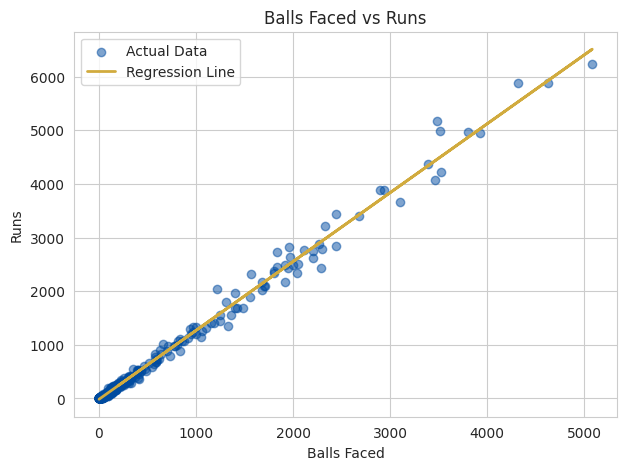

In [49]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color=NAVY,alpha=0.5, label="Actual Data")
plt.plot(X_train, model.predict(X_train), color=GOLD, linewidth=2, label="Regression Line")
#plt.plot(X_train, y_train, color=GOLD, linewidth=2, label="Regression Line")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.title("Balls Faced vs Runs")
plt.legend()
plt.show()

In [53]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "balls_faced": X_test["balls_faced"].values,
    "actual_runs": y_test.values,
    "predicted_runs": np.round(y_pred,1)
})
comparison.head(10)

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6
5,865,985,1095.6
6,26,34,18.1
7,9,12,-3.8
8,18,20,7.8
9,703,920,887.6


In [56]:
new_players = pd.DataFrame({"balls_faced":[100, 300, 60]})
new_preds = model.predict(new_players)

for balls, runs in zip(new_players["balls_faced"], new_preds):
  print(f"Balls faced = {balls} -> predicted_runs = {runs:.0f}")


Balls faced = 100 -> predicted_runs = 113
Balls faced = 300 -> predicted_runs = 370
Balls faced = 60 -> predicted_runs = 62
